In [1]:
import torch
import torchvision
from torch.utils.data import Dataset, random_split
from torchvision import transforms
from torchvision.io import read_image
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import os
from datetime import datetime
from PIL import Image
from diffusers import UNet2DModel, DDPMScheduler
import pandas as pd
import nrrd
import numpy as np
import torchvision.utils as vutils
torchvision.disable_beta_transforms_warning()

device = torch.device("cuda")
print(f"Using device: {device}")

/mnt/raid/home/ajarry/.conda/envs/difmod/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/mnt/raid/home/ajarry/.conda/envs/difmod/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Pl

Using device: cuda


In [2]:
parquet = "/mnt/raid/C1_ML_Analysis/CSV_files/extract_frames_Dataset_C_masked_resampled_256_spc075_wscores_meta_noflyto_1e-4.parquet"
df = pd.read_parquet(parquet, engine="pyarrow")

class DatasetFromDataFrame(Dataset):
    def __init__(self, root_dir, dataframe, transform=None):
        self.root_dir = root_dir
        self.df = dataframe
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for i in range(df.shape[0]):
            img_name = df.iloc[i,0]
            self.image_paths.append(os.path.join(self.root_dir,img_name))
            self.labels.append(0)
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        data, header = nrrd.read(img_path)
        data = np.squeeze(data)
        normalized = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-5)
        scaled_data = (normalized * 255)
        scaled_data = scaled_data[0].astype(np.uint8)
        image = Image.fromarray(scaled_data).convert('RGB')
        image = image.rotate(270)
    

        if self.transform:
            image = self.transform(image)
        
        label = int(self.labels[idx])

        return image, label

In [3]:
transform = transforms.Compose([
    transforms.Resize((256,256)),  
    transforms.ToTensor(),  
])

18320


(-0.5, 2065.5, 259.5, -0.5)

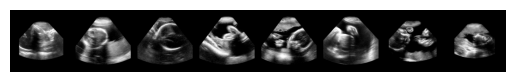

In [4]:
train_root_dir = '/mnt/raid/C1_ML_Analysis'

full_dataset = DatasetFromDataFrame(root_dir=train_root_dir,dataframe=df,transform=transform)

train_ratio = 0.8
train_size = int(train_ratio * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


batch_size = 8
# View some examples
train_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
print(train_dataloader.__len__())
x, y = next(iter(train_dataloader))

plt.imshow(torchvision.utils.make_grid(x)[0], cmap='gray')
plt.axis('off')

/mnt/raid/home/ajarry/.conda/envs/difmod/lib/python3.10/site-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


torch.Size([8, 3, 256, 256])


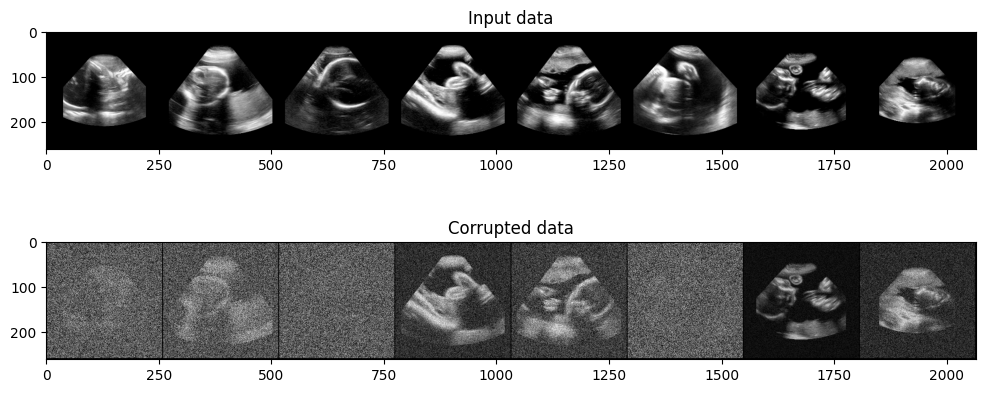

In [5]:
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
timesteps = torch.randint(0, scheduler.num_train_timesteps, (batch_size,)).long()

# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap="gray")

# Adding noise
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(original_samples=x, noise=noise, timesteps=timesteps)


print(x.shape)
# Plotting the noised version
axs[1].set_title("Corrupted data")
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap="gray")

In [6]:
class BasicUNet(nn.Module):
    """A minimal UNet implementation."""

    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ]
        )
        self.up_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.ReLU()  # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))  # Through the layer and the activation function
            if i < 2:  # For all but the third (final) down layer:
                h.append(x)  # Storing output for skip connection
                x = self.downscale(x)  # Downscale ready for the next layer

        for i, l in enumerate(self.up_layers):
            if i > 0:  # For all except the first up layer
                x = self.upscale(x)  # Upscale
                x += h.pop()  # Fetching stored output (skip connection)
            x = self.act(l(x))  # Through the layer and the activation function

        return x

In [7]:
# Dataloader (you can mess with batch size)
batch_size = 8
num_workers = 4
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)

# How many runs through the data should we do?
n_epochs = 1

# Create the network
net = UNet2DModel()
net.to(device)

# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-4)

# Keeping a record of the losses for later viewing
train_losses = []
val_losses = []

# Define directory for saving checkpoints
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"outputs_diffusers/output_{timestamp}/"
os.makedirs(output_dir, exist_ok=True)

# The training loop
for epoch in range(n_epochs):

    net.train()
    
    for x, y in train_dataloader:
        # Get some data and prepare the corrupted version
        x = x.to(device)  # Data on the GPU
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (x.size(0),)).to(device)

        noise = torch.rand_like(x)
        noise = noise.to(device)

        # Get the model prediction
        noisy_images = scheduler.add_noise(x, noise, timesteps)
        pred = net(noisy_images, timesteps).sample

        # Calculate the loss
        train_loss = loss_fn(pred, x)  # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        train_loss.backward()
        opt.step()

        # Store the loss for later
        train_losses.append(train_loss.item())

    # Validation phase
    net.eval()
    with torch.no_grad():
        for x, y in val_dataloader:
            x = x.to(device)
            timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (x.size(0),), device=device)
            outputs = net(x,timesteps).sample
            val_loss = loss_fn(outputs,x)
            

    # Print our the average of the loss values for this epoch:
    avg_train_loss = sum(train_losses[-len(train_dataloader) :]) / len(train_dataloader)
    avg_val_loss = sum(val_losses) / len(val_dataloader)
    print(f"Finished epoch {epoch}. Average loss for this epoch: {avg_train_loss:05f}. Average validation loss: {avg_val_loss:05f}")
    checkpoint_filename = f"checkpoint_epoch_{epoch+1}.pth"
    checkpoint_path = os.path.join(output_dir, checkpoint_filename)

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': net.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        }
    torch.save(checkpoint, checkpoint_path)

# View the loss curve
plt.plot(train_losses)
final_model_path = os.path.join(output_dir, "model.pth")
torch.save(net.state_dict(), final_model_path)


KeyboardInterrupt: 

: 